# Run 7 — Analysis & Export

Loads saved checkpoints and result JSONs from run7. No training.

**Prerequisites**: run7 must be complete and results synced to Drive.
- `results/ablations/run7/_final_config.json`
- `results/ablations/run7/*.json`
- `models/run7/{winner_name}.pt`

| Section | What it does |
|---|---|
| §2 | Training curves / overfitting (reads JSONs only) |
| §3 | Best-model per-shot accuracy & recall |
| §4 | Best-model confusion analysis (needs GPU + checkpoint) |
| §5 | Per-shot F1 across every ablation variant (a1, a2, b1, b2, b3, …) |
| §6 | Class distribution (reads dataset only) |
| §7 | Shuttle coverage (reads dataset only) |
| §8 | Diagnostic summary |
| §9 | Cross-attention weight visualisation (needs cross-attn winner) |


In [1]:
import os, sys, json
from pathlib import Path

try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    import zipfile
    if not (PROJECT_PATH / 'src').exists():
        with zipfile.ZipFile(DRIVE_ROOT / 'baddiev2_colab.zip') as z:
            z.extractall(PROJECT_PATH)
    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)
else:
    PROJECT_PATH = Path('..').resolve()
    if not (PROJECT_PATH / 'src').exists():
        PROJECT_PATH = Path('.').resolve()
    DRIVE_ROOT = PROJECT_PATH
    if str(PROJECT_PATH) not in sys.path:
        sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

import src.config as _cfg

if IN_COLAB:
    _cfg.SS_CSV_ROOT        = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV       = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SKELETONS_GDINO = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.SS_SHUTTLES        = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_shuttles'
    _cfg.SS_SPLIT_JSON      = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'
    _cfg.MODELS_DIR         = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR        = DRIVE_ROOT / 'results'

    # dataset.py did `from ..config import SS_CSV_ROOT` — a value-binding import,
    # so reassigning _cfg.SS_CSV_ROOT above does NOT reach it. Patch its module
    # namespace directly. (The CSVs live on Drive, not in baddiev2_colab.zip.)
    import src.data.dataset as _ds_mod
    _ds_mod.SS_CSV_ROOT = _cfg.SS_CSV_ROOT
    assert Path(_ds_mod.SS_CSV_ROOT).exists(), (
        f"ShuttleSet CSVs not found at {_ds_mod.SS_CSV_ROOT} — "
        f"upload datasets/ShuttleSet/set/ to Drive."
    )

print(f'Project: {PROJECT_PATH}')
print(f'Colab: {IN_COLAB}')

Mounted at /content/drive
Project: /content/Baddiev2
Colab: True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader, Dataset as _Dataset
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

from src.config import (
    FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER, BONE_CHANNELS, COCO_SKELETON,
    SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
    SHOT_TYPES, NUM_SHOT_TYPES, NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
)
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.shuttle_cross_attn import ShuttleCrossAttention

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)

N_CLASSES     = NUM_SHOT_TYPES
SHOT_WINDOW   = 32
BATCH_SIZE    = 64
ABLATION_DIR  = RESULTS_DIR / 'ablations' / 'run7'
MODELS_DIR_R7 = MODELS_DIR  / 'run7'

# Data directories — reuse training's local SSD paths so we read the same already-
# copied data and avoid the silent-shuttle-dropping bug. The previous '/content/
# local_skel' path could be left in a partial state by an earlier analysis run,
# missing frame_nums.npy → ShuttleSetDataset falls to per_shot mode and silently
# drops shuttle → every C3 cross-attn sample becomes all_masked.
if IN_COLAB:
    local_skel  = Path('/content/local_skeletons')
    local_shutt = Path('/content/local_shuttles')
    import shutil
    if not local_skel.exists():
        print('Copying skeletons to /content/local_skeletons ...')
        shutil.copytree(_cfg.SS_SKELETONS_GDINO, local_skel)
    if not local_shutt.exists():
        print('Copying shuttles to /content/local_shuttles ...')
        shutil.copytree(_cfg.SS_SHUTTLES, local_shutt)
    SKEL_DIR  = local_skel
    SHUTT_DIR = local_shutt
else:
    SKEL_DIR  = _cfg.SS_SKELETONS_GDINO
    SHUTT_DIR = _cfg.SS_SHUTTLES

# Sanity-check the skeleton layout. ShuttleSetDataset only loads shuttle in
# whole_match mode (needs frame_nums.npy + skeletons.npy per match dir). A per_shot
# layout silently drops shuttle → every cross-attn sample becomes all_masked.
_sample_match = next((d for d in SKEL_DIR.iterdir() if d.is_dir()), None)
if _sample_match is not None:
    _has_fn = (_sample_match / 'frame_nums.npy').exists()
    _has_sk = (_sample_match / 'skeletons.npy').exists()
    _mode_str = 'whole_match (shuttle OK)' if _has_fn and _has_sk else 'per_shot (shuttle DROPPED)'
    print(f'Skeleton layout @ {_sample_match.name}: frame_nums.npy={_has_fn}  skeletons.npy={_has_sk}  → {_mode_str}')
    assert _has_fn and _has_sk, (
        f'{SKEL_DIR} is not in whole_match layout — shuttle will be silently dropped. '
        f'Re-copy from {_cfg.SS_SKELETONS_GDINO} (or rm -rf the partial dir and re-run).'
    )

print(f'Device: {device}')
print(f'N_CLASSES: {N_CLASSES}')
print(f'Ablation dir: {ABLATION_DIR}')
print(f'SKEL_DIR : {SKEL_DIR}')
print(f'SHUTT_DIR: {SHUTT_DIR}')

Copying skeletons to /content/local_skeletons ...
Copying shuttles to /content/local_shuttles ...
Skeleton layout @ Hans-Kristian_Solberg_Vittinghus_Lee_Cheuk_Yu_TOYOTA_THAILAND_OPEN_2021_QuarterFinals: frame_nums.npy=True  skeletons.npy=True  → whole_match (shuttle OK)
Device: cpu
N_CLASSES: 15
Ablation dir: /content/drive/MyDrive/Baddiev2/results/ablations/run7
SKEL_DIR : /content/local_skeletons
SHUTT_DIR: /content/local_shuttles


In [3]:
# ── Helper functions ──────────────────────────────────────────────────────

class SinglePlayerWrapper(_Dataset):
    """Extract only the hitter's 17 joints from a dual-player dataset."""
    def __init__(self, ds):
        self.ds = ds
        self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x, label = item[0], item[1]
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label


class SinglePlayerCrossAttnWrapper(_Dataset):
    """Hitter 17 joints + preserved shuttle tensor. For cross-attn + single player."""
    def __init__(self, ds):
        self.ds = ds
        self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item     = self.ds[idx]
        x, label = item[0], item[1]
        shuttle  = item[2] if len(item) == 3 else torch.zeros(2, x.shape[1])
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label, shuttle


def collate_fn(batch):
    xs, labels = zip(*[(b[0], b[1]) for b in batch])
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)


def collate_fn_shuttle(batch):
    xs, labels, shuttles = [], [], []
    for item in batch:
        xs.append(item[0]); labels.append(item[1])
        shuttles.append(item[2] if len(item) == 3 else torch.zeros(2, SHOT_WINDOW))
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long), torch.stack(shuttles)


def build_encoder(in_channels, num_nodes=NUM_NODES, pooling='mean'):
    single = (num_nodes == NUM_JOINTS)
    adj = GraphBuilder(use_inter_player=not single, single_player=single).build_adjacency().to(device)
    return STGCN(in_channels=in_channels, num_nodes=num_nodes, adjacency=adj,
                 num_layers=9, base_channels=64, embedding_dim=256,
                 temporal_kernel=9, dropout=0.3, pooling=pooling).to(device)


def compute_class_weights(dataset):
    labels  = [s.get('shot_type_idx') for s in dataset.samples
               if s.get('shot_type_idx') is not None]
    counts  = Counter(labels)
    total   = sum(counts.values())
    weights = torch.ones(N_CLASSES, dtype=torch.float32)
    for cls_id, cnt in counts.items():
        if cls_id < N_CLASSES:
            weights[cls_id] = total / (len(counts) * cnt)
    return weights


def evaluate(encoder, head, ds, cross_attn=None):
    cfn    = collate_fn_shuttle if cross_attn else collate_fn
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, collate_fn=cfn)
    encoder.eval(); head.eval()
    if cross_attn: cross_attn.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            xb, yb = batch[0], batch[1]; valid = yb >= 0
            if not valid.any(): continue
            emb = encoder(xb[valid].to(device))
            if cross_attn: emb = cross_attn(emb, batch[2][valid].to(device))
            all_logits.append(head(emb).cpu()); all_labels.append(yb[valid])
    if not all_logits: return 0.0, 0.0, np.array([]), np.array([]), {}
    logits = torch.cat(all_logits); y_true = torch.cat(all_labels).numpy()
    y_pred = logits.argmax(1).numpy()
    topk = {f'top{k}_acc': logits.topk(k,1).indices.eq(
                torch.tensor(y_true).unsqueeze(1)).any(1).float().mean().item()
            for k in [3, 5] if logits.shape[1] >= k}
    return (f1_score(y_true, y_pred, average='macro', zero_division=0),
            accuracy_score(y_true, y_pred), y_true, y_pred, topk)


print('Helpers defined.')

Helpers defined.


In [4]:
# ── Load final config + splits ────────────────────────────────────────────
with open(ABLATION_DIR / '_final_config.json') as f:
    fc = json.load(f)

# Derive fields the JSON doesn't store (training built fc dynamically; saved JSON is minimal).
fc.setdefault(
    'in_channels',
    (FEATURE_DIMS_WITH_HITTER if fc['use_hitter'] else FEATURE_DIMS)[fc['feature_layer']]
    + (BONE_CHANNELS if fc['use_bones'] else 0),
)
fc.setdefault('num_nodes', NUM_JOINTS if fc['single_player'] else NUM_NODES)
with open(SS_SPLIT_JSON) as f:
    splits = json.load(f)

VAL_MATCH_NAMES = [
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
]
TRAIN_MATCHES = set(splits['train']) - set(VAL_MATCH_NAMES)
VAL_MATCHES   = set(VAL_MATCH_NAMES)
TEST_MATCHES  = set(splits['held_out'])
ALL_MATCHES   = set(splits['train']) | set(splits['held_out'])

print(f'Winner: {fc["winner_name"]}')
print(f'Config: {fc}')
print(f'Train: {len(TRAIN_MATCHES)}  Val: {len(VAL_MATCHES)}  Test: {len(TEST_MATCHES)}')

Winner: C3_shuttle_xattn
Config: {'winner_name': 'C3_shuttle_xattn', 'feature_layer': 'L3', 'single_player': True, 'use_hitter': False, 'use_bones': True, 'use_bbox_norm': False, 'variable_window': False, 'pooling': 'attn', 'use_shuttle': True, 'shuttle_fusion': 'cross_attn', 'in_channels': 16, 'num_nodes': 17}
Train: 17  Val: 2  Test: 2


## §2 — Training Information & Overfitting

Reads per-variant training history from the result JSONs in `results/ablations/run7/`. No model load / no dataset — pure JSON read.

Look for: (a) final train loss near zero ⇒ memorised the train set; (b) large best-val-F1 vs. test-F1 gap ⇒ val/test distributions diverge; (c) val curve still climbing at the stop epoch ⇒ early-stop kicked in too soon.

Loaded 22 result files

Name                             Ep  FinalLoss  BestValF1   TestF1      Gap
------------------------------------------------------------------------------
A1_dual_L2                       30     0.1129     0.5618   0.5949  -0.0331
A2_dual_L3                       24     0.1828     0.5533   0.5660  -0.0127
A3_single_L2                     17     0.4975     0.5431   0.5523  -0.0092
A4_single_L3                     38     0.0892     0.5636   0.6171  -0.0535
A5_dual_L2_hitter                37     0.0530     0.5523   0.5832  -0.0309
A6_dual_L3_hitter                37     0.0539     0.5639   0.5671  -0.0032
A7_bones_only                    30     0.2009     0.5906   0.6557  -0.0651
A8_bones                         30     0.2239     0.5775   0.6242  -0.0467
B1_fixed_window                  30     0.2239     0.5775   0.6242  -0.0467
B2+_variable_window_pad          28     0.4500     0.5795   0.5991  -0.0196
B2_variable_window               23     0.4874     0.5691   0

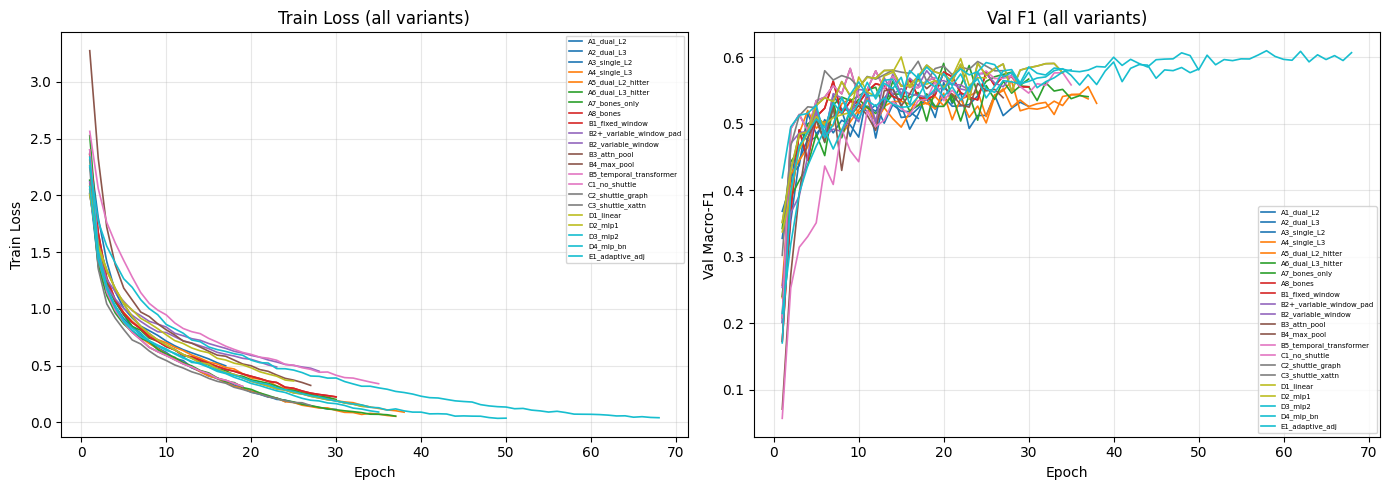

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/overfitting_analysis.png


In [5]:
# ── §2 — Overfitting Analysis ─────────────────────────────────────────────
# Reads JSON history only — no model or dataset needed.

all_res = {}
for p in sorted(ABLATION_DIR.glob('*.json')):
    if p.stem.startswith('_'): continue
    try: all_res[p.stem] = json.load(open(p))
    except: pass
print(f'Loaded {len(all_res)} result files')

print(f'\n{"Name":<30} {"Ep":>4} {"FinalLoss":>10} {"BestValF1":>10} {"TestF1":>8} {"Gap":>8}')
print('-' * 78)
for nm in sorted(all_res):
    r = all_res[nm]
    if not isinstance(r, dict):
        continue
    h = r.get('history', {})
    fl  = h['train_loss'][-1] if h.get('train_loss') else None
    bv  = r.get('best_val_f1'); tf = r.get('macro_f1')
    gap = bv - tf if bv is not None and tf is not None else None
    print(f'{nm:<30} {r["stopped_epoch"]:>4} '
          f'{"%10.4f" % fl if fl is not None else "%11s" % "N/A"} '
          f'{"%10.4f" % bv if bv is not None else "%11s" % "N/A"} '
          f'{"%8.4f" % tf if tf is not None else "%9s" % "N/A"} '
          f'{"%+8.4f" % gap if gap is not None else "N/A"}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
_colors = plt.cm.tab10(np.linspace(0, 1, max(len(all_res), 1)))
for (nm, r), c in zip(sorted(all_res.items()), _colors):
    h = r.get('history', {})
    if h.get('train_loss'):
        ax1.plot(range(1, len(h['train_loss'])+1), h['train_loss'], label=nm, color=c, lw=1.2)
    if h.get('val_f1'):
        ax2.plot(range(1, len(h['val_f1'])+1), h['val_f1'], label=nm, color=c, lw=1.2)
ax1.set(xlabel='Epoch', ylabel='Train Loss', title='Train Loss (all variants)')
ax2.set(xlabel='Epoch', ylabel='Val Macro-F1', title='Val F1 (all variants)')
for ax in (ax1, ax2): ax.legend(fontsize=5); ax.grid(True, alpha=0.3)
plt.tight_layout()
out = ABLATION_DIR / 'overfitting_analysis.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

## §3 — Best-Model Per-Shot Accuracy & Recall

For the overall winner (read from `_final_config.json`), report per-shot-type precision, recall, F1, and accuracy (recall on the support row). Reads `_final_config.json` + the winner's result JSON — no checkpoint load needed; we use the per-class report saved at training time.

Why two metrics: a class can have *high precision but low recall* (the model rarely predicts it, but is right when it does) or vice versa. Both numbers matter for shot-type classification because the cost of missing a smash differs from the cost of mislabelling a clear as a smash.

Best model: C3_shuttle_xattn   Macro-F1 0.6894   Accuracy 0.7333

Shot type                    prec  recall     F1     n
------------------------------------------------------
net shot                    0.855   0.878  0.867   296
push                        0.741   0.633  0.683   226
return net                  0.842   0.687  0.757   163
lob                         0.613   0.854  0.713   137
short service               0.985   0.985  0.985   133
clear                       0.913   0.899  0.906   129
smash                       0.621   0.551  0.584   107
drive                       0.729   0.481  0.580   106
passive drop                0.632   0.625  0.629    88
wrist smash                 0.451   0.493  0.471    75
cross-court net shot        0.661   0.651  0.656    63
drop                        0.416   0.607  0.493    61
rush                        0.610   0.806  0.694    31
defensive return lob        0.333   0.625  0.435     8
long service                0.800   1.000  0.889     4

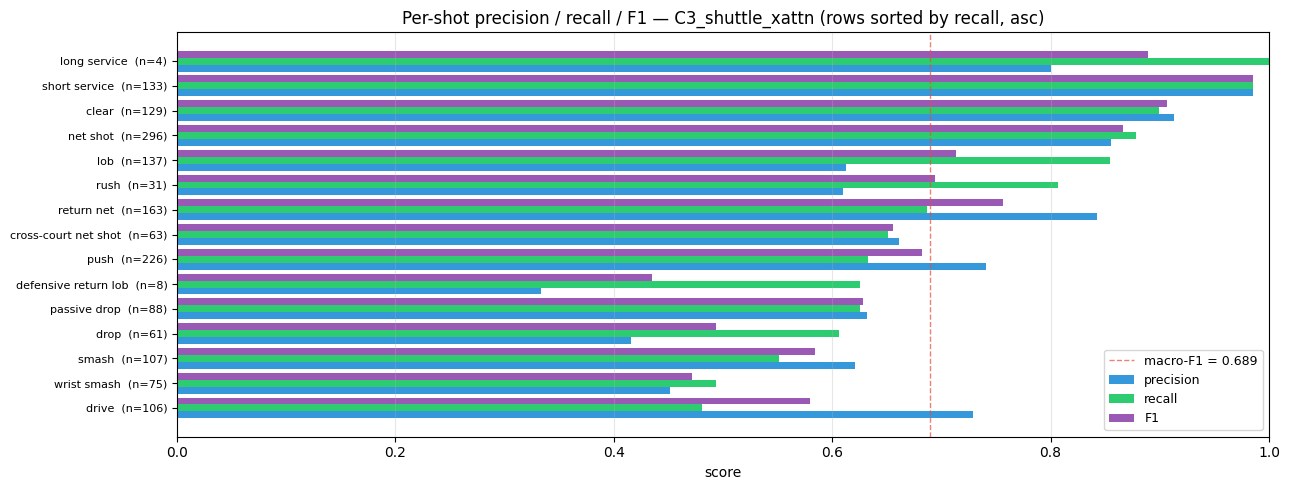


Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/best_per_shot_prec_rec_f1.png


In [6]:
# ── §3 — Per-shot precision / recall / F1 for the best model ─────────────
# Uses the per_class block sklearn writes into each ablation JSON.
# No GPU / no checkpoint — pure JSON read.

best_res = json.load(open(ABLATION_DIR / f'{fc["winner_name"]}.json'))
pc = best_res.get('per_class', {})
if not pc:
    raise RuntimeError(f'No per_class block in {fc["winner_name"]}.json — re-export from training.')

# Skip sklearn's aggregate rows.
_skip = {'accuracy', 'macro avg', 'weighted avg', 'micro avg'}
rows = [(name, v.get('precision', 0.0), v.get('recall', 0.0), v.get('f1-score', 0.0), int(v.get('support', 0)))
        for name, v in pc.items() if name not in _skip]
# Order by support desc so the rare-class story reads naturally.
rows.sort(key=lambda r: -r[4])

print(f'Best model: {fc["winner_name"]}   '
      f'Macro-F1 {best_res["macro_f1"]:.4f}   Accuracy {best_res["accuracy"]:.4f}\n')
print(f'{"Shot type":<26} {"prec":>6} {"recall":>7} {"F1":>6} {"n":>5}')
print('-' * 54)
for name, prec, rec, f1, sup in rows:
    print(f'{name:<26} {prec:>6.3f} {rec:>7.3f} {f1:>6.3f} {sup:>5d}')

# Bar chart: side-by-side precision & recall per class, sorted by recall.
rows_by_rec = sorted(rows, key=lambda r: r[2])      # ascending recall → worst first
names  = [r[0] for r in rows_by_rec]
precs  = np.array([r[1] for r in rows_by_rec])
recs   = np.array([r[2] for r in rows_by_rec])
f1s    = np.array([r[3] for r in rows_by_rec])
sups   = np.array([r[4] for r in rows_by_rec])

fig, ax = plt.subplots(figsize=(13, 5))
y    = np.arange(len(names))
h    = 0.28
ax.barh(y - h, precs, h, color='#3498db', label='precision')
ax.barh(y,     recs,  h, color='#2ecc71', label='recall')
ax.barh(y + h, f1s,   h, color='#9b59b6', label='F1')
ax.set_yticks(y)
ax.set_yticklabels([f'{n}  (n={s})' for n, s in zip(names, sups)], fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel('score')
ax.set_title(f'Per-shot precision / recall / F1 — {fc["winner_name"]} '
             f'(rows sorted by recall, asc)')
ax.axvline(best_res['macro_f1'], color='#e74c3c', ls='--', lw=1, alpha=0.7,
           label=f'macro-F1 = {best_res["macro_f1"]:.3f}')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
out = ABLATION_DIR / 'best_per_shot_prec_rec_f1.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'\nSaved: {out}')


## §4 — Best-Model Confusion Analysis

Loads the winner's checkpoint, re-runs inference on the held-out test matches, and renders counts + row-normalised confusion matrices. The top-15 confusion-pair list at the end is the per-class story: where does the model trade one shot type for another?

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Dataset mode: whole_match   first-sample returns shuttle: True
Test samples: 1675
Accuracy:    0.7333
Macro-F1:    0.6894
Top-3 Acc: 0.9514
Top-5 Acc: 0.9852


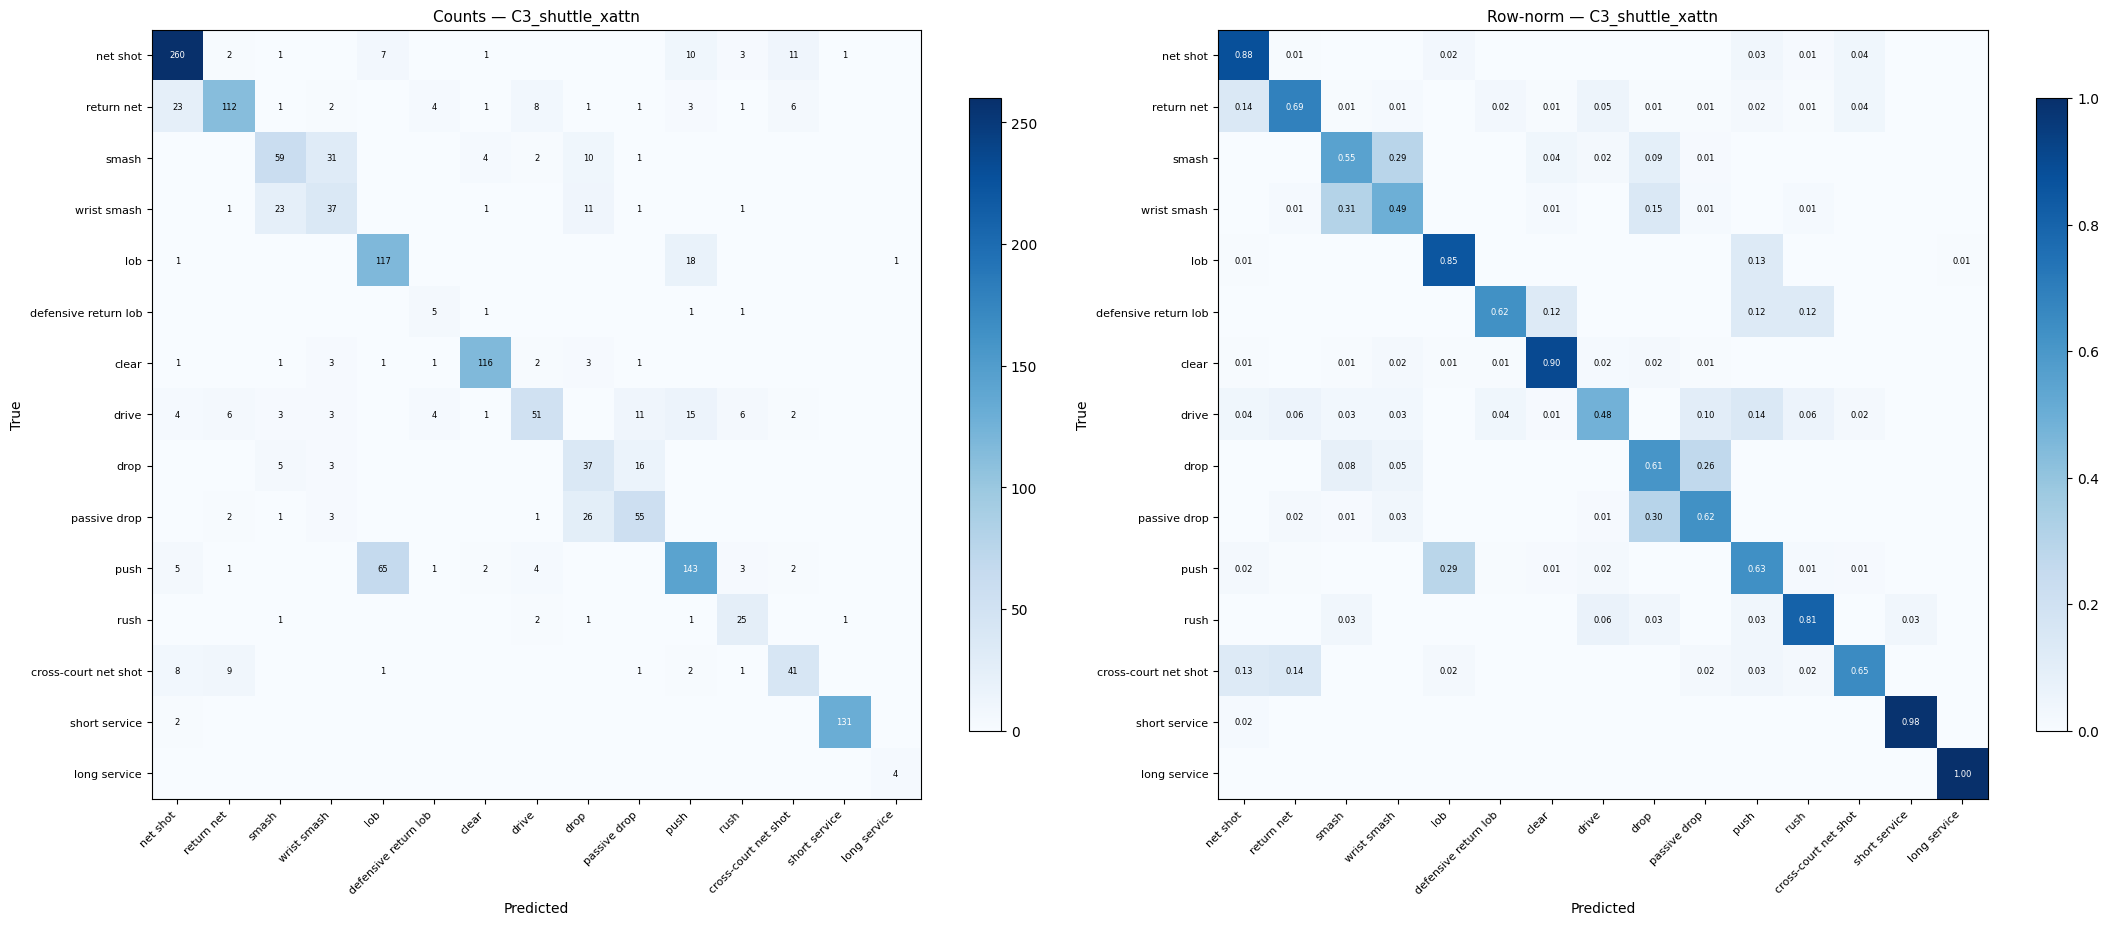

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/confusion_matrix_C3_shuttle_xattn.png

Top 15 confusion pairs:
  push                     → lob                      :   65 (29% of true push)
  smash                    → wrist smash              :   31 (29% of true smash)
  passive drop             → drop                     :   26 (30% of true passive drop)
  wrist smash              → smash                    :   23 (31% of true wrist smash)
  return net               → net shot                 :   23 (14% of true return net)
  lob                      → push                     :   18 (13% of true lob)
  drop                     → passive drop             :   16 (26% of true drop)
  drive                    → push                     :   15 (14% of true drive)
  wrist smash              → drop                     :   11 (15% of true wrist smash)
  drive                    → passive drop             :   11 (10% of true drive)
  net shot                 → cross-court net 

In [7]:
# ── §4 — Best-Model Confusion Matrix ─────────────────────────────────────────────────
# Loads checkpoint and runs inference on test set.

def _make_test_ds(fc, match_set):
    ds = ShuttleSetDataset(
        skeleton_dir=SKEL_DIR, shot_window=SHOT_WINDOW,
        feature_layer=fc['feature_layer'], load_shot_types=True, split=None,
        use_shuttle=fc['use_shuttle'], shuttle_dir=SHUTT_DIR if fc['use_shuttle'] else None,
        variable_window=fc['variable_window'], shuttle_fusion=fc['shuttle_fusion'],
        use_hitter=fc['use_hitter'], use_bones=fc['use_bones'], use_bbox_norm=fc['use_bbox_norm'],
    )
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in match_set]
    if fc['single_player']:
        if fc['use_shuttle'] and fc['shuttle_fusion'] == 'cross_attn':
            return SinglePlayerCrossAttnWrapper(ds)
        return SinglePlayerWrapper(ds)
    return ds


def _load_model(fc):
    ckpt = torch.load(MODELS_DIR_R7 / f'{fc["winner_name"]}.pt',
                      map_location=device, weights_only=True)
    enc  = build_encoder(fc['in_channels'], num_nodes=fc['num_nodes'], pooling=fc['pooling'])
    enc.load_state_dict(ckpt['enc']);  enc.eval()
    head = nn.Linear(256, N_CLASSES).to(device)
    head.load_state_dict(ckpt['head']); head.eval()
    ca = None
    if fc['use_shuttle'] and fc['shuttle_fusion'] == 'cross_attn':
        ca = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
        ca.load_state_dict(ckpt['ca']); ca.eval()
    return enc, head, ca


test_ds = _make_test_ds(fc, TEST_MATCHES)

# Sanity-check: confirm shuttle is actually being returned by the dataset.
# If fc['use_shuttle']=True but the dataset returns only (x, label) — i.e. mode
# fell to per_shot — every C3 cross-attn sample becomes all_masked and all
# downstream attention plots will be empty.
if fc.get('use_shuttle') and fc.get('shuttle_fusion') == 'cross_attn' and len(test_ds) > 0:
    _ds_under = test_ds.ds if hasattr(test_ds, 'ds') else test_ds
    _mode = getattr(_ds_under, '_mode', '?')
    _probe = test_ds[0]
    _has_shuttle = len(_probe) == 3 and _probe[2].abs().sum().item() > 0
    print(f'Dataset mode: {_mode}   first-sample returns shuttle: {_has_shuttle}')
    assert _has_shuttle, (
        f"Dataset is dropping shuttle (mode={_mode}). Check SKEL_DIR layout — "
        f"needs frame_nums.npy + skeletons.npy per match dir for whole_match mode."
    )
enc, head, ca = _load_model(fc)
print(f'Test samples: {len(test_ds)}')

if len(test_ds) == 0:
    print("\n[!] ERROR: test_ds is empty. Ensure individual shot files exist in the match directories.")
    y_true = y_pred = np.array([])
else:
    _macro_f1, _accuracy, y_true, y_pred, topk = evaluate(enc, head, test_ds, ca)
    for k in [1, 3, 5]:
        if k == 1:
            print(f'Accuracy:    {_accuracy:.4f}')
            print(f'Macro-F1:    {_macro_f1:.4f}')
        else:
            print(f'Top-{k} Acc: {topk.get(f"top{k}_acc", 0):.4f}')

if len(y_true) > 0:
    _present = sorted(set(y_true) | set(y_pred))
    _lnames  = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'cls_{i}' for i in _present]
    _cm      = confusion_matrix(y_true, y_pred, labels=_present)
    _cm_norm = _cm.astype(float) / _cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
    for ax, data, title, fmt, vmax in [
        (ax1, _cm,      f'Counts — {fc["winner_name"]}', 'd',   None),
        (ax2, _cm_norm, f'Row-norm — {fc["winner_name"]}', '.2f', 1),
    ]:
        kw = {'vmin': 0, 'vmax': vmax} if vmax else {}
        im = ax.imshow(data, interpolation='nearest', cmap='Blues', **kw)
        ax.set_title(title, fontsize=11)
        ax.set_xticks(range(len(_lnames))); ax.set_yticks(range(len(_lnames)))
        ax.set_xticklabels(_lnames, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(_lnames, fontsize=8)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        thresh = data.max() * 0.5 if vmax is None else 0.5
        for i in range(len(_lnames)):
            for j in range(len(_lnames)):
                val = data[i, j]
                if (val > 0.005 if isinstance(val, float) else val > 0):
                    ax.text(j, i, format(val, fmt), ha='center', va='center',
                            fontsize=6, color='white' if val > thresh else 'black')
        fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    out = ABLATION_DIR / f'confusion_matrix_{fc["winner_name"]}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
    print(f'Saved: {out}')

    _pairs = [(int(_cm[i,j]), float(_cm_norm[i,j]), _lnames[i], _lnames[j])
              for i in range(len(_lnames)) for j in range(len(_lnames))
              if i != j and _cm[i,j] > 0]
    _pairs.sort(reverse=True)
    print('\nTop 15 confusion pairs:')
    for cnt, frac, tc, pc in _pairs[:15]:
        print(f'  {tc:<24} → {pc:<24} : {cnt:4d} ({frac:.0%} of true {tc})')
else:
    print("\nSkipping confusion matrix due to empty predictions.")

## §5 — Per-Shot F1 Across Every Ablation Variant

Reads each ablation JSON in `results/ablations/run7/` and stacks the per-class F1 from its saved `per_class` block into a single matrix (rows = shot types, cols = variants A1, A2, …, B1, B2, B3, …, C1, C2, …, D1, …). Lets you see *which variant helps which shot type* — not just the aggregate macro-F1.

Variants are listed in filename order; the winner column is highlighted. Use this to spot e.g. "the cross-attention variant helped smash but hurt drive" patterns that the single macro-F1 number hides.

Shot type                      n               A1_dual_L2              A2_dual_L3            A3_single_L2            A4_single_L3       A5_dual_L2_hitter       A6_dual_L3_hitter           A7_bones_only                A8_bones         B1_fixed_window B2+_variable_window_pad      B2_variable_window            B3_attn_pool             B4_max_pool B5_temporal_transformer           C1_no_shuttle        C2_shuttle_graph        C3_shuttle_xattn               D1_linear                 D2_mlp1                 D3_mlp2               D4_mlp_bn         E1_adaptive_adj
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

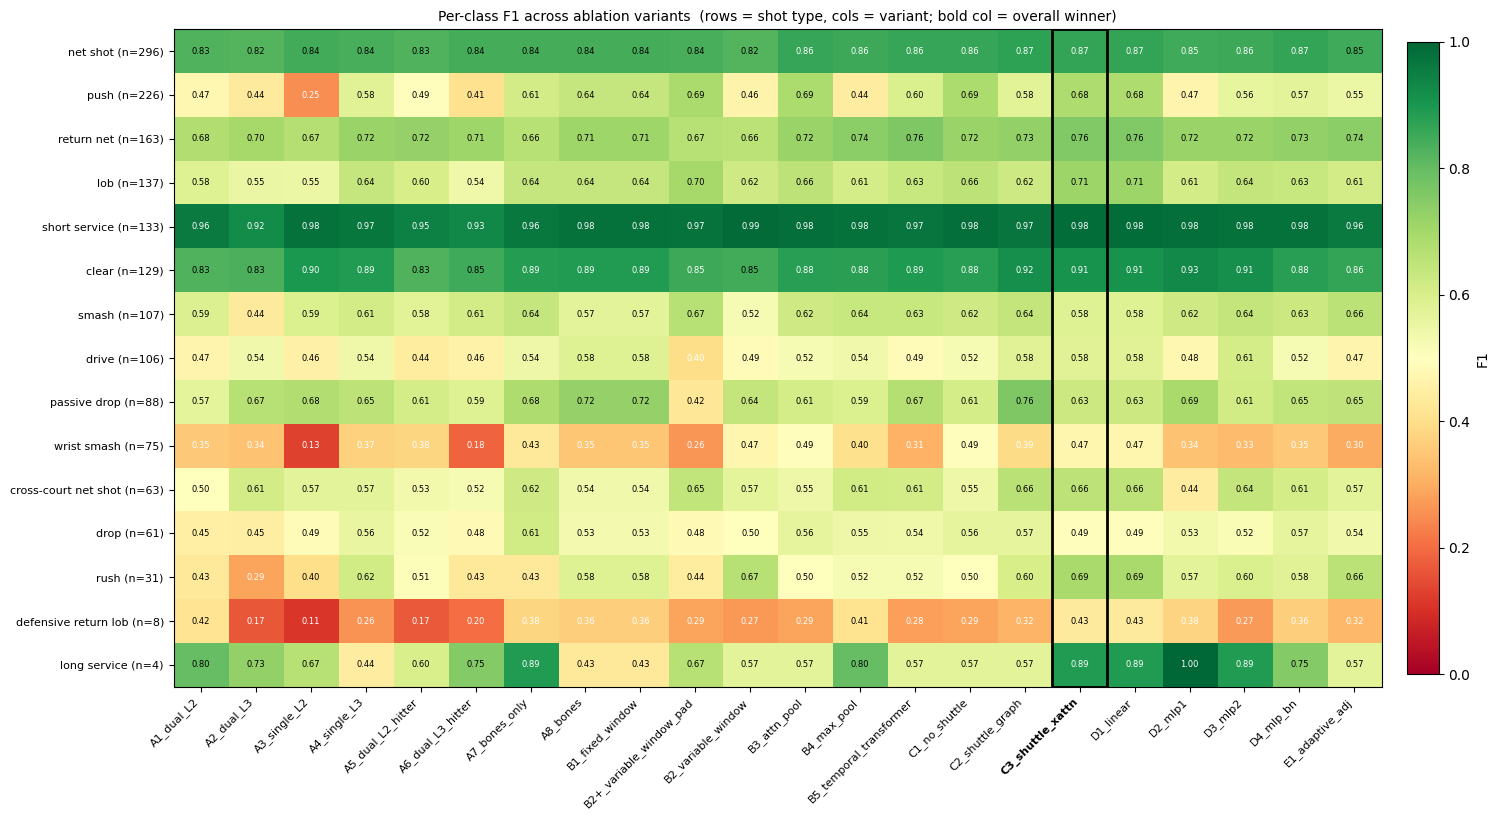


Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/per_shot_f1_by_variant.png

Best variant per shot type:
Shot type                  best variant               F1   winner F1   Δ vs winner
----------------------------------------------------------------------------------
net shot                   C2_shuttle_graph        0.875       0.867        +0.008
push                       B2+_variable_window_pad  0.691       0.683        +0.009
return net                 B5_temporal_transformer  0.758       0.757        +0.001
lob                        C3_shuttle_xattn        0.713       0.713        +0.000   <- winner
short service              B2_variable_window      0.989       0.985        +0.004
clear                      D2_mlp1                 0.927       0.906        +0.021
smash                      B2+_variable_window_pad  0.667       0.584        +0.083
drive                      D3_mlp2                 0.608       0.580        +0.029
passive drop               C2_shuttl

In [8]:
# ── §5 — Per-class F1 across every ablation variant ──────────────────────
# One row per shot type, one column per variant file. Each cell = F1 from
# that variant's saved per_class block. Variants are sorted by their
# leading prefix (A1, A2, ..., A10, B1, ..., C1, ..., D1, ...).

import re
_KEY_RE = re.compile(r'^([A-Za-z])(\d+)')

def _variant_key(stem):
    m = _KEY_RE.match(stem)
    if not m:
        return ('Z', 999, stem)            # files without a prefix sort last
    return (m.group(1).upper(), int(m.group(2)), stem)

_files = [p for p in sorted(ABLATION_DIR.glob('*.json'))
          if not p.stem.startswith('_')]
_files.sort(key=lambda p: _variant_key(p.stem))

variant_names, variant_macro, per_class_rows = [], [], {}
for p in _files:
    try:
        r = json.load(open(p))
    except Exception:
        continue
    if not isinstance(r, dict) or 'per_class' not in r:
        continue
    variant_names.append(p.stem)
    variant_macro.append(r.get('macro_f1'))
    for cls, v in r['per_class'].items():
        if cls in ('accuracy', 'macro avg', 'weighted avg', 'micro avg'):
            continue
        per_class_rows.setdefault(cls, {})[p.stem] = v.get('f1-score', np.nan)

if not variant_names:
    raise RuntimeError(f'No per_class data found in {ABLATION_DIR}. Re-export per-class from training.')

# Stable row order: by support in the winner, descending. Fall back to first variant.
_ref = json.load(open(ABLATION_DIR / f'{fc["winner_name"]}.json')).get('per_class', {})
if not _ref:
    _ref = json.load(open(ABLATION_DIR / f'{variant_names[0]}.json')).get('per_class', {})
_support = {k: int(v.get('support', 0)) for k, v in _ref.items()
            if k not in ('accuracy', 'macro avg', 'weighted avg', 'micro avg')}
class_order = sorted(per_class_rows.keys(), key=lambda c: -_support.get(c, 0))

F = np.full((len(class_order), len(variant_names)), np.nan)
for i, cls in enumerate(class_order):
    for j, nm in enumerate(variant_names):
        F[i, j] = per_class_rows[cls].get(nm, np.nan)

# ── Printable table ──────────────────────────────────────────────────────
_w = max(8, max((len(n) for n in variant_names), default=8))
_hdr = f'{"Shot type":<26} {"n":>5}  ' + ' '.join(f'{n:>{_w}}' for n in variant_names)
print(_hdr)
print('-' * len(_hdr))
for i, cls in enumerate(class_order):
    row = ' '.join(
        ('   nan' if np.isnan(F[i, j]) else f'{F[i, j]:>{_w}.3f}')
        for j in range(len(variant_names))
    )
    print(f'{cls:<26} {_support.get(cls, 0):>5}  {row}')
print('-' * len(_hdr))
_macro_row = ' '.join(
    ('   nan' if m is None else f'{m:>{_w}.3f}') for m in variant_macro
)
print(f'{"MACRO-F1":<26} {"-":>5}  {_macro_row}')

# ── Heatmap ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(0.55 * len(variant_names) + 3, 0.42 * len(class_order) + 2))
im = ax.imshow(F, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks(range(len(variant_names)))
ax.set_xticklabels(variant_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(class_order)))
ax.set_yticklabels([f'{c} (n={_support.get(c, 0)})' for c in class_order], fontsize=8)
if fc['winner_name'] in variant_names:
    wi = variant_names.index(fc['winner_name'])
    ax.add_patch(plt.Rectangle((wi - 0.5, -0.5), 1, len(class_order),
                                fill=False, edgecolor='black', lw=2))
    ax.get_xticklabels()[wi].set_fontweight('bold')
for i in range(F.shape[0]):
    for j in range(F.shape[1]):
        v = F[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if v < 0.4 or v > 0.85 else 'black')
ax.set_title('Per-class F1 across ablation variants  '
             '(rows = shot type, cols = variant; bold col = overall winner)', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='F1')
plt.tight_layout()
out = ABLATION_DIR / 'per_shot_f1_by_variant.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'\nSaved: {out}')

# ── Best variant per shot type (where does the winner *not* win?) ─────────
print('\nBest variant per shot type:')
print(f'{"Shot type":<26} {"best variant":<22} {"F1":>6}  '
      f'{"winner F1":>10} {"Δ vs winner":>13}')
print('-' * 82)
win_col = variant_names.index(fc['winner_name']) if fc['winner_name'] in variant_names else None
for i, cls in enumerate(class_order):
    row = F[i]
    if np.all(np.isnan(row)):
        continue
    j = int(np.nanargmax(row))
    wf = F[i, win_col] if win_col is not None and not np.isnan(F[i, win_col]) else np.nan
    delta = (row[j] - wf) if not np.isnan(wf) else np.nan
    mark = '   <- winner' if (win_col is not None and j == win_col) else ''
    print(f'{cls:<26} {variant_names[j]:<22} {row[j]:>6.3f}  '
          f'{("%10.3f" % wf) if not np.isnan(wf) else ("%10s" % "-")} '
          f'{("%+13.3f" % delta) if not np.isnan(delta) else ("%13s" % "-")}{mark}')


## §6 — Class Distribution (train / val / test)

Sanity check: how many shots per class in each split. Compare against the per-shot F1 in §3 — small-support classes with low F1 are the obvious candidates for class re-weighting or merging.

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Train: 14933 labeled samples
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Val: 2077 labeled samples
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Test: 1627 labeled samples

ID   Shot Type                    Train    Tr%    Val   Test   Total
-----------------------------------------------------------------
0    net shot                      2872  19.2%    487    296    3655
1    return net                    1569  10.5%    221    163    1953
2    smash                         1158   7.8%    141    107    1406
3    wrist smash                    694   4.6%     99     75     868
4    lob                           2499  16.7%    410    137    3046
5    defensive return lob           136   0.9%     25      8     169
6    clear                          883   5.9%    140    129    1152
7    drive                

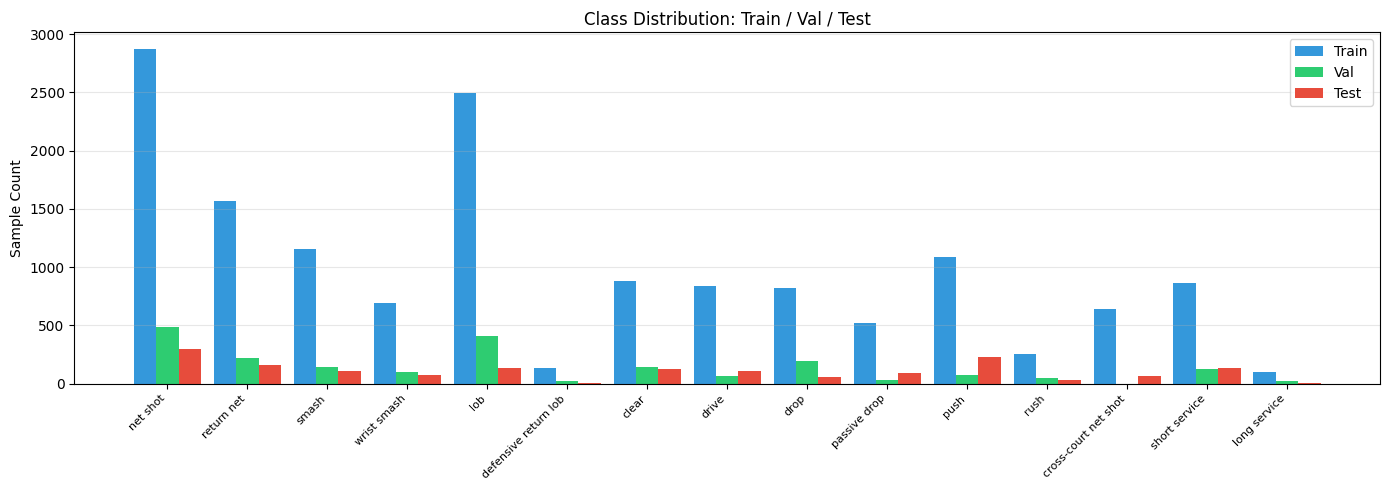

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/class_distribution.png


In [9]:
# ── §6 — Class Distribution ───────────────────────────────────────────────

def _label_counts(match_set, label):
    ds = ShuttleSetDataset(skeleton_dir=SKEL_DIR, shot_window=SHOT_WINDOW,
                           feature_layer='L2', load_shot_types=True, split=None)
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in match_set]
    labels = [s.get('shot_type_idx') for s in ds.samples if s.get('shot_type_idx') is not None]
    print(f'{label}: {len(labels)} labeled samples')
    return Counter(labels)

tr_cnt = _label_counts(TRAIN_MATCHES, 'Train')
va_cnt = _label_counts(VAL_MATCHES,   'Val')
te_cnt = _label_counts(TEST_MATCHES,  'Test')
all_cls = sorted(set(tr_cnt) | set(va_cnt) | set(te_cnt))
tot_tr  = sum(tr_cnt.values())

print(f'\n{"ID":<4} {"Shot Type":<26} {"Train":>7} {"Tr%":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
print('-' * 65)
for c in all_cls:
    nm = SHOT_TYPES[c] if c < len(SHOT_TYPES) else f'cls_{c}'
    tr = tr_cnt.get(c, 0); va = va_cnt.get(c, 0); te = te_cnt.get(c, 0)
    print(f'{c:<4} {nm:<26} {tr:>7} {tr/tot_tr*100:>5.1f}% {va:>6} {te:>6} {tr+va+te:>7}')
print(f'     {"TOTAL":<26} {tot_tr:>7} {"100%":>6} {sum(va_cnt.values()):>6} '
      f'{sum(te_cnt.values()):>6} {tot_tr+sum(va_cnt.values())+sum(te_cnt.values()):>7}')
print(f'\nImbalance: {max(tr_cnt.values())}/{min(tr_cnt.values())} = '
      f'{max(tr_cnt.values())/min(tr_cnt.values()):.1f}x')

fig, ax = plt.subplots(figsize=(14, 5))
_names = [SHOT_TYPES[c] if c < len(SHOT_TYPES) else f'cls_{c}' for c in all_cls]
_x = np.arange(len(all_cls)); _w = 0.28
ax.bar(_x-_w, [tr_cnt.get(c,0) for c in all_cls], _w, label='Train', color='#3498db')
ax.bar(_x,    [va_cnt.get(c,0) for c in all_cls], _w, label='Val',   color='#2ecc71')
ax.bar(_x+_w, [te_cnt.get(c,0) for c in all_cls], _w, label='Test',  color='#e74c3c')
ax.set_xticks(_x); ax.set_xticklabels(_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sample Count'); ax.set_title('Class Distribution: Train / Val / Test')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
out = ABLATION_DIR / 'class_distribution.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

## §7 — Shuttle Trajectory Coverage

What fraction of training samples have *any* shuttle data, and how densely is the shot window tracked when data exists. Sets the ceiling on how much the shuttle-fusion variants in §5 can actually help.

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
Checking 2000 of 19470 samples...
With shuttle: 1739/2000 (87.0%)
Frame density (samples with data): mean=73.9%  median=81.2%


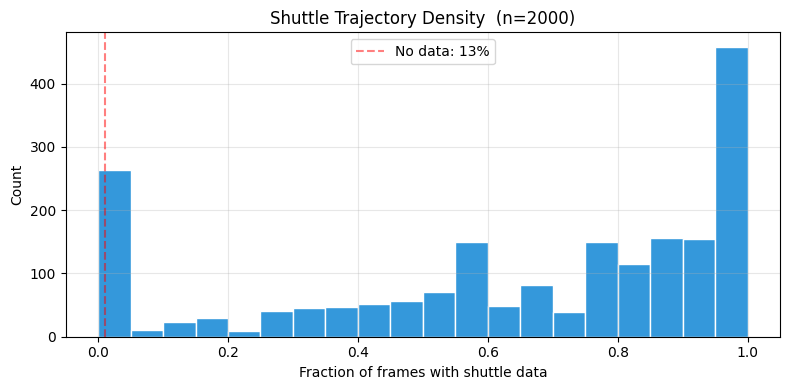

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/shuttle_coverage.png


In [10]:
# ── §7 — Shuttle Coverage ─────────────────────────────────────────────────

ds_sh = ShuttleSetDataset(
    skeleton_dir=SKEL_DIR, shot_window=SHOT_WINDOW, feature_layer='L2',
    load_shot_types=True, split=None,
    use_shuttle=True, shuttle_dir=SHUTT_DIR, shuttle_fusion='cross_attn',
)
ds_sh.samples = [s for s in ds_sh.samples
                 if isinstance(s, dict) and Path(s.get('skel_dir','')).name in ALL_MATCHES]

_n_check = min(len(ds_sh), 2000)
_rng = np.random.default_rng(42)
_idx = _rng.choice(len(ds_sh), size=_n_check, replace=False)
print(f'Checking {_n_check} of {len(ds_sh)} samples...')

_n_has = 0; _dens = []
for i in _idx:
    item = ds_sh[int(i)]
    if len(item) >= 3:
        sh = item[2].numpy() if hasattr(item[2], 'numpy') else item[2]
        has = np.any(sh[:2] != 0)
        _n_has += int(has)
        _dens.append(np.any(sh[:2] != 0, axis=0).mean())

_pct = _n_has / _n_check * 100
print(f'With shuttle: {_n_has}/{_n_check} ({_pct:.1f}%)')
_pos = np.array(_dens); _pos = _pos[_pos > 0]
if len(_pos) > 0:
    print(f'Frame density (samples with data): mean={_pos.mean():.1%}  median={np.median(_pos):.1%}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.array(_dens), bins=20, color='#3498db', edgecolor='white')
ax.set_xlabel('Fraction of frames with shuttle data'); ax.set_ylabel('Count')
ax.set_title(f'Shuttle Trajectory Density  (n={_n_check})')
ax.axvline(x=0.01, color='red', ls='--', alpha=0.5, label=f'No data: {100-_pct:.0f}%')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
out = ABLATION_DIR / 'shuttle_coverage.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

## §8 — Diagnostic Summary

Roll-up across all earlier sections. Depends on `_pairs` (§4), `tr_cnt` (§6), `_pct` (§7), `all_res` (§2).

In [11]:
# ── §8 — Diagnostic Summary ───────────────────────────────────────────────
# Depends on: _pairs (§4), tr_cnt (§6), _pct (§7), all_res (§2)

best_res = json.load(open(ABLATION_DIR / f'{fc["winner_name"]}.json'))
print('=' * 70)
print('DIAGNOSTIC SUMMARY')
print('=' * 70)
print(f'\n1. BEST CONFIG: {fc["winner_name"]}')
print(f'   Test Macro-F1: {best_res["macro_f1"]:.4f}')
print(f'   Test Accuracy: {best_res["accuracy"]:.4f}')
print(f'   Top-3 Acc:     {best_res.get("top3_acc", "N/A")}')
print(f'   Top-5 Acc:     {best_res.get("top5_acc", "N/A")}')
print(f'\n2. CONFIG FLAGS:')
for k, v in fc.items():
    print(f'   {k}: {v}')
print(f'\n3. CLASS IMBALANCE:')
print(f'   Largest: {max(tr_cnt.values())}  Smallest: {min(tr_cnt.values())}  '
      f'Ratio: {max(tr_cnt.values())/min(tr_cnt.values()):.1f}x')
print(f'\n4. SHUTTLE COVERAGE: {_pct:.1f}% of samples have trajectory data')
print(f'\n5. TOP 5 CONFUSION PAIRS:')
for cnt, frac, tc, pc in _pairs[:5]:
    print(f'   {tc} → {pc}: {cnt} ({frac:.0%})')
print(f'\n6. WORST CLASSES BY F1:')
_pc   = best_res.get('per_class', {})
_cf1s = [(v.get('f1-score', 0), v.get('support', 0), k) for k, v in _pc.items()
         if k not in ('accuracy', 'macro avg', 'weighted avg')]
for f1, sup, nm in sorted(_cf1s)[:5]:
    print(f'   {nm:<24} F1={f1:.2f}  (n={sup})')
_h = best_res.get('history', {})
if _h.get('train_loss'):
    bv = best_res['best_val_f1']; tf = best_res['macro_f1']
    print(f'\n7. OVERFITTING:')
    print(f'   Final train loss: {_h["train_loss"][-1]:.4f}')
    print(f'   Best val F1:      {bv:.4f}')
    print(f'   Test F1:          {tf:.4f}')
    print(f'   Gap:              {bv-tf:+.4f} ({"OK" if abs(bv-tf)<0.03 else "notable"})')
print(f'\n8. EVALUATION CAVEAT:')
print(f'   Test set = 2 matches ({len(y_true)} shots). Differences < 0.02 F1 may not be reliable.')
print(f'   Run §9 cross-validation (in run7 notebook) for robust estimates.')

DIAGNOSTIC SUMMARY

1. BEST CONFIG: C3_shuttle_xattn
   Test Macro-F1: 0.6894
   Test Accuracy: 0.7333
   Top-3 Acc:     0.9514
   Top-5 Acc:     0.9852

2. CONFIG FLAGS:
   winner_name: C3_shuttle_xattn
   feature_layer: L3
   single_player: True
   use_hitter: False
   use_bones: True
   use_bbox_norm: False
   variable_window: False
   pooling: attn
   use_shuttle: True
   shuttle_fusion: cross_attn
   in_channels: 16
   num_nodes: 17

3. CLASS IMBALANCE:
   Largest: 2872  Smallest: 100  Ratio: 28.7x

4. SHUTTLE COVERAGE: 87.0% of samples have trajectory data

5. TOP 5 CONFUSION PAIRS:
   push → lob: 65 (29%)
   smash → wrist smash: 31 (29%)
   passive drop → drop: 26 (30%)
   wrist smash → smash: 23 (31%)
   return net → net shot: 23 (14%)

6. WORST CLASSES BY F1:
   defensive return lob     F1=0.43  (n=8.0)
   wrist smash              F1=0.47  (n=75.0)
   drop                     F1=0.49  (n=61.0)
   drive                    F1=0.58  (n=106.0)
   smash                    F1=0.58  

## §9 — Cross-Attention Weight Visualisation

For §5.4 (Group C, shuttle fusion): show *where in the shot window* the cross-attention head looks per shot type. The query is a single token (skeleton embedding), so each shot produces one length-T attention distribution over the shuttle context.

**Expected pattern** if attention is doing real work: smash/drop peak near contact (t=16); clear/drive spread out. A uniform pattern across types would mean the +2.6 F1 from cross-attn comes from feature presence, not learned routing.

Requires §8a to have loaded a cross-attn winner (`ca` is not `None`).

In [12]:
# §9a — Capture per-sample cross-attention weights ─────────────────────
# Reads attention weights via a forward hook on the MultiheadAttention
# submodule (ca.cross_attn). This works with the *unmodified* model file:
# nn.MultiheadAttention returns (attn_output, attn_weights) by default, and
# the hook grabs the weights the model otherwise discards.

assert ca is not None, (
    "Cross-attention model not loaded — current config does not use "
    "shuttle_fusion='cross_attn'. Re-run §8a with a cross-attn winner first."
)


def _collect_attn(encoder, head_, cross_attn, ds):
    """Return list of dicts {label, pred, attn[T], shuttle[2,T], all_masked, frame_num}."""
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, collate_fn=collate_fn_shuttle)
    encoder.eval(); head_.eval(); cross_attn.eval()

    # Forward hook on the inner MHA — output is (attn_output, attn_weights),
    # weights shape (B, 1, T) averaged over heads.
    _cap = {}
    def _hook(_module, _inp, out):
        _cap['w'] = out[1].detach().cpu()
    handle = cross_attn.cross_attn.register_forward_hook(_hook)

    raw_samples = ds.ds.samples if hasattr(ds, 'ds') else ds.samples
    rows, cursor = [], 0
    try:
        with torch.no_grad():
            for xb, yb, sb in loader:
                valid = yb >= 0
                if valid.any():
                    xv = xb[valid].to(device)
                    sv = sb[valid].to(device)
                    yv = yb[valid]
                    emb   = encoder(xv)
                    _cap.clear()
                    fused = cross_attn(emb, sv)
                    preds = head_(fused).argmax(1).cpu().numpy()
                    # Per-sample "no shuttle data" flag (all positions zero).
                    masked = (sv.abs().sum(dim=1) == 0).all(dim=1).cpu().numpy()
                    if 'w' in _cap:
                        attn = _cap['w'].squeeze(1).numpy()        # (Bv, T)
                    else:
                        # Whole batch all-masked → model short-circuits, MHA never runs.
                        attn = np.zeros((int(valid.sum()), sv.shape[-1]))
                    v_pos = torch.nonzero(valid, as_tuple=False).flatten().tolist()
                    for j, pos in enumerate(v_pos):
                        samp = raw_samples[cursor + pos]
                        rows.append({
                            'label':       int(yv[j]),
                            'pred':        int(preds[j]),
                            'attn':        attn[j],
                            'shuttle':     sb[pos].numpy(),
                            'all_masked':  bool(masked[j]),
                            'frame_num':   int(samp.get('frame_num', 0)) if isinstance(samp, dict) else 0,
                            'rally_key':   samp.get('rally_key', '')   if isinstance(samp, dict) else '',
                        })
                cursor += len(yb)
    finally:
        handle.remove()
    return rows


attn_rows = _collect_attn(enc, head, ca, test_ds)
_n_total   = len(attn_rows)
_n_masked  = sum(r['all_masked'] for r in attn_rows)
print(f'Collected attention for {_n_total} samples '
      f'({_n_total - _n_masked} with shuttle data, {_n_masked} all-masked)')


Collected attention for 1627 samples (1613 with shuttle data, 14 all-masked)


### §9b — How to read the cross-attention figures

The cross-attention head produces, for each shot, **one length-T (T=32) probability distribution** over the shuttle-trajectory frames — "where in the shot window did the model look." The four diagrams below summarise that distribution across all 15 shot types.

**Mean attention vs. other attention.** "Mean" is only one way to summarise the distribution, and on its own it can mislead — read it alongside the other three columns of the §9b·1 table:

| Metric | What it tells you |
|---|---|
| **mean curve** (blue line, §9b·1) | the per-type *average* distribution — the robust signal. A bump near contact (t=16) means the model consistently routes attention to the hit frame for that shot type. |
| **±1σ band** (grey, §9b·1) | per-shot spread. A wide band means the mean is averaging over very different individual distributions — the "type pattern" is weak. |
| **peak / max** | height of the single most-attended frame. High peak + low entropy ⇒ sharply focused; low peak ⇒ diffuse. The heatmap colour (§9b·2) reads as peak. |
| **entropy** | spread of the distribution (nats; max = ln 32 ≈ 3.47). Low ⇒ concentrated on a few frames; near 3.47 ⇒ effectively uniform. |
| **argmax t** | *which* frame carries the most attention. The comparison that matters: if smash peaks early and clear peaks late, the model learned shot-specific temporal routing rather than a fixed prior. |

**§9b·2 (heatmap)** puts every shot type on one axis, rows sorted by `argmax t`, so cross-type comparison is direct — a clean early→late diagonal is the signature of genuine routing.

**Caveat.** Mean attention can be high at a frame simply because the shuttle was *visible* there — the model cannot attend to masked frames. So a "contact peak" may be a visibility artefact, not learned behaviour. §9b is **descriptive**; **§9c** is the actual test — it subtracts a "uniform-over-visible" null to isolate the learned routing component.

**§9b·3 / §9b·4** (2D height-vs-frame, 3D x/t/y path) show one well-tracked example shot per type — context for *what the shuttle was doing* at the frames the model attended to. They are illustrative, not statistical.

> Run order: **§9a → §9b·1 → §9b·2 → §9b·3 → §9b·4**. §9b·1 defines `by_type`, `rows_present`, `_entropy`, `_coverage` that the others reuse.


Shot types with test data: 15 / 15


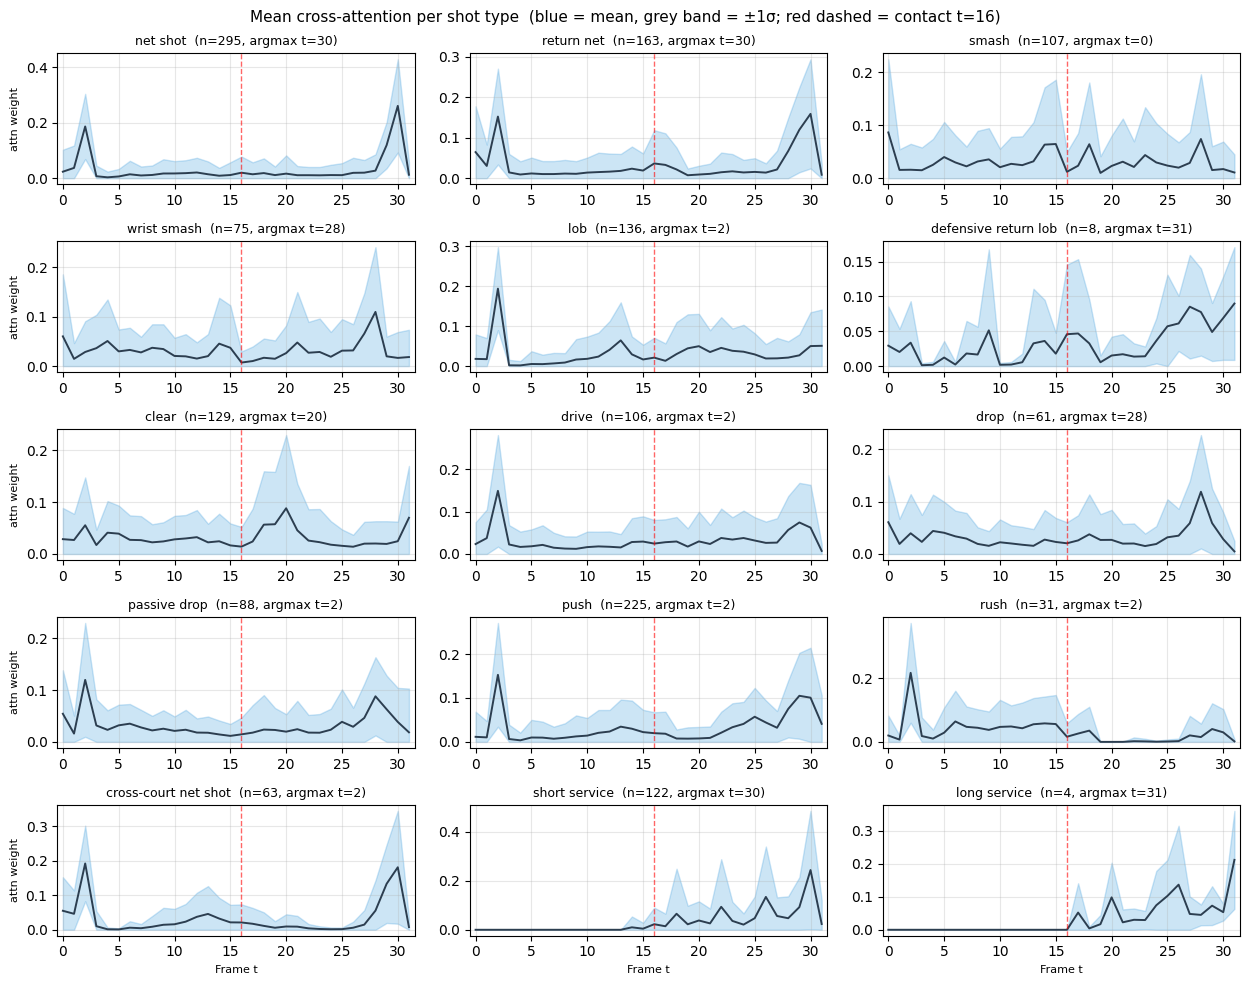

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/xattn_mean_per_type.png

Shot type                    n  argmax t    peak  @contact   entropy
------------------------------------------------------------------
net shot                   295        30   0.260     0.020     2.701
return net                 163        30   0.159     0.036     2.956
smash                      107         0   0.086     0.012     3.307
wrist smash                 75        28   0.110     0.007     3.305
lob                        136         2   0.194     0.021     3.096
defensive return lob         8        31   0.090     0.046     3.126
clear                      129        20   0.088     0.014     3.340
drive                      106         2   0.149     0.025     3.239
drop                        61        28   0.119     0.020     3.301
passive drop                88         2   0.120     0.015     3.278
push                       225         2   0.153     0.020     3.036
rush              

In [13]:
# ── §9b·1 — Mean attention per shot type (blue line + grey ±1σ band) ─────
# Robust §5.4 figure. For every shot type with test data, the per-type
# average of the cross-attention distribution over all its test shots.
# Peak near contact (t=16) ⇒ the model routes attention to the hit frame
# for that shot type. Defines by_type / rows_present / helpers reused by
# §9b·2–4. Also prints the argmax / peak / @contact / entropy table.

CONTACT_FRAME = SHOT_WINDOW // 2  # t=16
t = np.arange(SHOT_WINDOW)


def _entropy(p):
    """Shannon entropy of an attention distribution (nats; max = ln T ≈ 3.47)."""
    p = np.asarray(p) + 1e-12
    return -float((p * np.log(p)).sum())


def _coverage(sh):
    """Fraction of the T-frame window where the shuttle was tracked."""
    xs, ys = sh[0], sh[1]
    return float(((xs != 0) | (ys != 0)).mean())


# Every shot type that actually has test shots with shuttle data.
by_type = {}
for cid, name in enumerate(SHOT_TYPES):
    rs = [r for r in attn_rows if r['label'] == cid and not r['all_masked']]
    if rs:
        by_type[name] = rs
rows_present = [SHOT_TYPES[c] for c in range(len(SHOT_TYPES))
                if SHOT_TYPES[c] in by_type]
print(f'Shot types with test data: {len(rows_present)} / {len(SHOT_TYPES)}')

n    = len(rows_present)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 2.0 * nrow), squeeze=False)

stats = {}  # name -> (n, argmax, peak, @contact, entropy)
for k, name in enumerate(rows_present):
    rs     = by_type[name]
    A      = np.stack([r['attn'] for r in rs])      # (n, T)
    mean_a = A.mean(0)
    std_a  = A.std(0)
    stats[name] = (len(rs), int(mean_a.argmax()), float(mean_a.max()),
                   float(mean_a[CONTACT_FRAME]), _entropy(mean_a))

    ax = axes[k // ncol][k % ncol]
    ax.fill_between(t, np.clip(mean_a - std_a, 0, None), mean_a + std_a,
                    color='#3498db', alpha=0.25)
    ax.plot(t, mean_a, color='#2c3e50', lw=1.4)
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.6, lw=1)
    ax.set_title(f'{name}  (n={len(rs)}, argmax t={int(mean_a.argmax())})',
                 fontsize=9)
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3)
    if k % ncol == 0:
        ax.set_ylabel('attn weight', fontsize=8)
    if k // ncol == nrow - 1:
        ax.set_xlabel('Frame t', fontsize=8)

for k in range(n, nrow * ncol):           # blank unused axes
    axes[k // ncol][k % ncol].axis('off')

fig.suptitle('Mean cross-attention per shot type  '
             '(blue = mean, grey band = ±1σ; red dashed = contact t=16)',
             fontsize=11)
plt.tight_layout()
out = ABLATION_DIR / 'xattn_mean_per_type.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

# Aggregate metrics — argmax / peak / @contact / entropy of the mean curve.
print(f'\n{"Shot type":<24} {"n":>5} {"argmax t":>9} {"peak":>7} '
      f'{"@contact":>9} {"entropy":>9}')
print('-' * 66)
for name in rows_present:
    nshot, am, pk, atc, ent = stats[name]
    print(f'{name:<24} {nshot:>5} {am:>9} {pk:>7.3f} {atc:>9.3f} {ent:>9.3f}')


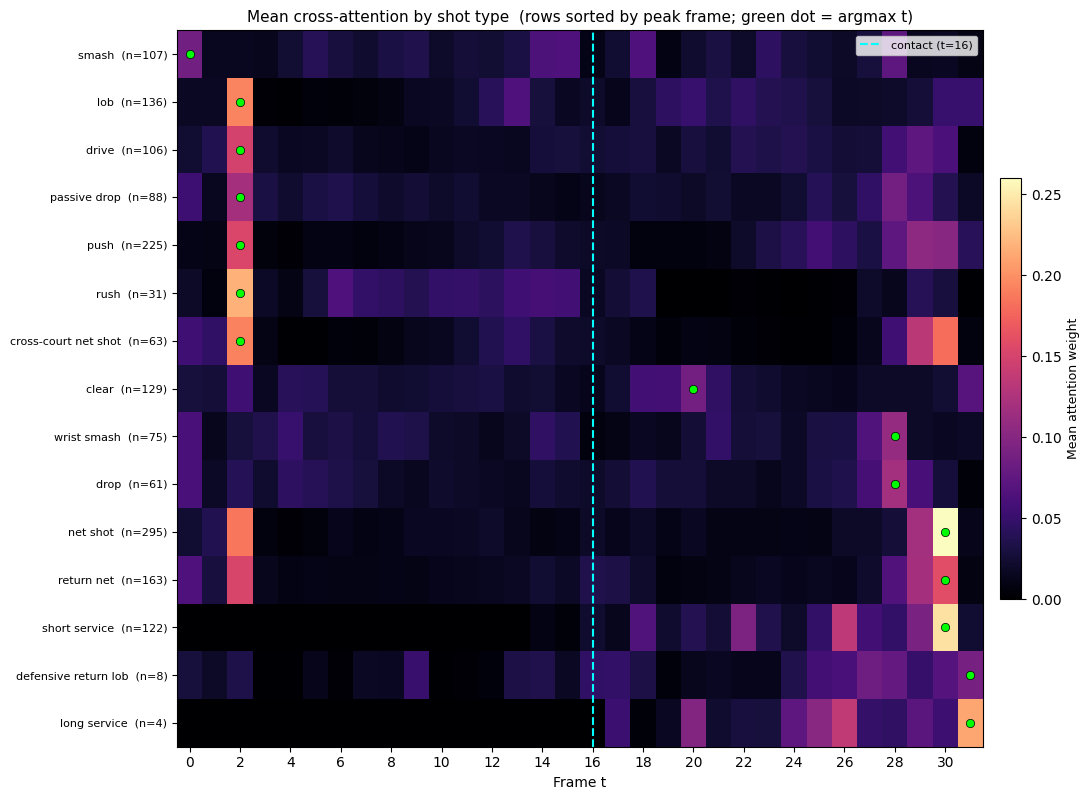

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/xattn_heatmap.png


In [14]:
# ── §9b·2 — Cross-type comparison: attention heatmap ────────────────────
# All shot types on one axis so each type's attention can be read against
# every other type's. Rows sorted by peak-attention frame (argmax t) — the
# early→late routing gradient becomes a visible diagonal if routing is real.
# Colour = mean attention weight, so "max / peak" reads straight off the map.
# Depends on by_type / rows_present from §9b·1 — run that first.

CONTACT_FRAME = SHOT_WINDOW // 2  # t=16

_means = {nm: np.stack([r['attn'] for r in by_type[nm]]).mean(0)
          for nm in rows_present}
order  = sorted(rows_present, key=lambda nm: int(_means[nm].argmax()))
mat    = np.stack([_means[nm] for nm in order])          # (n_types, T)

fig, ax = plt.subplots(figsize=(11, 0.42 * len(order) + 1.8))
im = ax.imshow(mat, aspect='auto', cmap='magma', interpolation='nearest')

ax.set_xticks(range(0, SHOT_WINDOW, 2))
ax.set_xlabel('Frame t')
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f'{nm}  (n={len(by_type[nm])})' for nm in order], fontsize=8)
ax.axvline(CONTACT_FRAME, color='cyan', ls='--', lw=1.5,
           label=f'contact (t={CONTACT_FRAME})')
for i, nm in enumerate(order):
    ax.plot(int(_means[nm].argmax()), i, 'o', color='lime',
            ms=6, mec='black', mew=0.5)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Mean cross-attention by shot type  '
             '(rows sorted by peak frame; green dot = argmax t)', fontsize=11)

cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('Mean attention weight', fontsize=9)

plt.tight_layout()
out = ABLATION_DIR / 'xattn_heatmap.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')


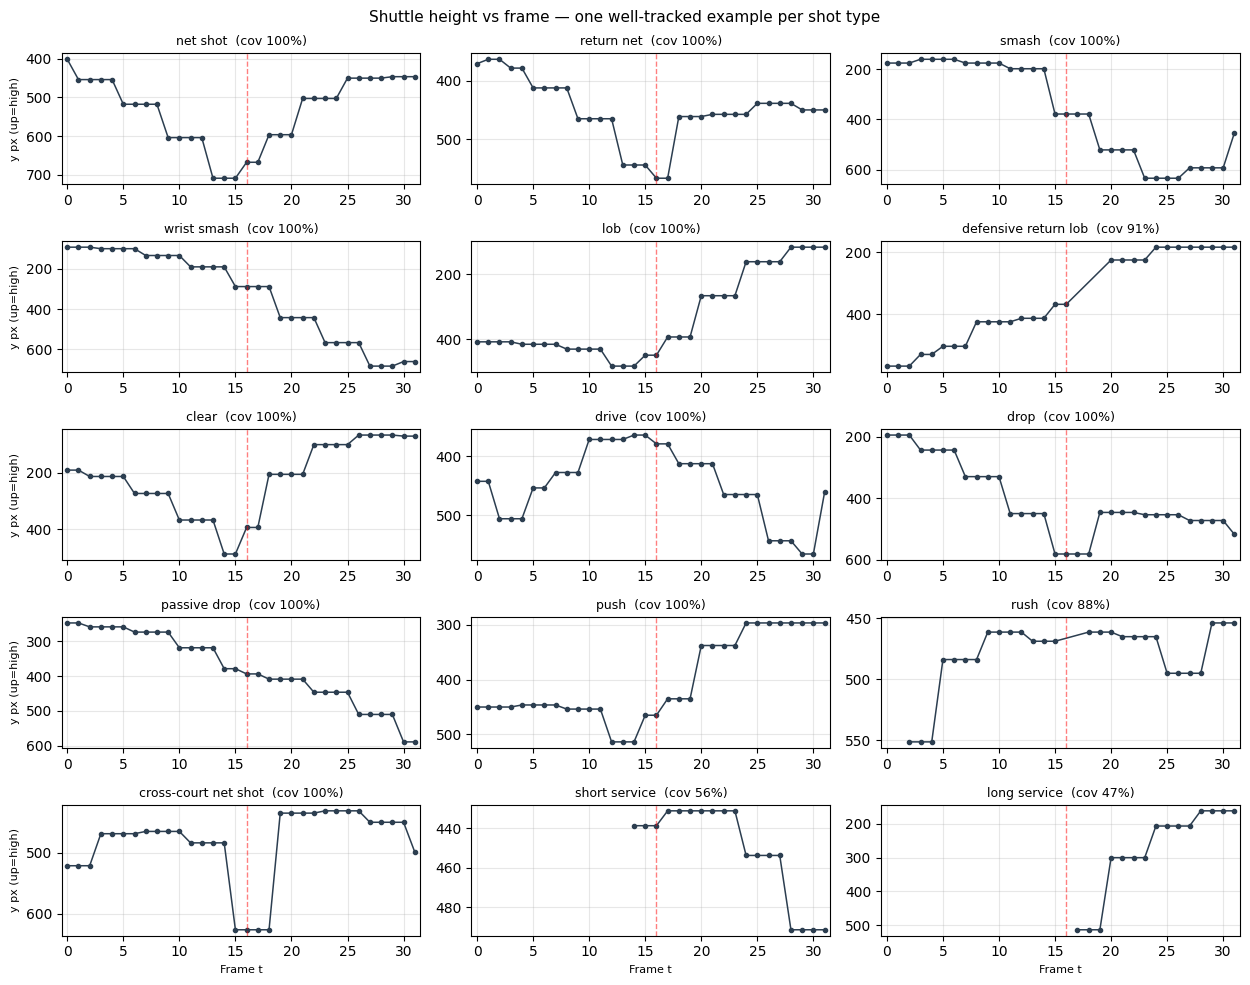

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/xattn_height_per_type.png


In [15]:
# ── §9b·3 — Shuttle height over the shot window, one example per type ───
# Shuttle y-pixel (inverted: up = high) vs frame t. Same x-axis as the
# attention plots, so the two line up. One well-tracked example per type
# (highest coverage, correct prediction). Shows what the shuttle was *doing*.
# Depends on by_type / rows_present / _coverage from §9b·1 — run that first.

CONTACT_FRAME = SHOT_WINDOW // 2  # t=16

n    = len(rows_present)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 2.0 * nrow), squeeze=False)

for k, name in enumerate(rows_present):
    rs    = by_type[name]
    cands = [r for r in rs if r['pred'] == r['label']] or rs
    ex    = sorted(cands, key=lambda r: (-_coverage(r['shuttle']),
                                         r['frame_num'], r['rally_key']))[0]
    sh = ex['shuttle']
    xs, ys  = sh[0], sh[1]
    visible = (xs != 0) | (ys != 0)
    ax = axes[k // ncol][k % ncol]
    if visible.any():
        vi = np.where(visible)[0]
        ax.plot(vi, ys[vi], '-o', color='#2c3e50', ms=3, lw=1.1)
    ax.axvline(CONTACT_FRAME, color='red', ls='--', alpha=0.5, lw=1)
    ax.invert_yaxis()  # image y grows downward → invert so up = high
    ax.set_title(f'{name}  (cov {_coverage(sh):.0%})', fontsize=9)
    ax.set_xlim(-0.5, SHOT_WINDOW - 0.5)
    ax.grid(True, alpha=0.3)
    if k % ncol == 0:
        ax.set_ylabel('y px (up=high)', fontsize=8)
    if k // ncol == nrow - 1:
        ax.set_xlabel('Frame t', fontsize=8)

for k in range(n, nrow * ncol):
    axes[k // ncol][k % ncol].axis('off')

fig.suptitle('Shuttle height vs frame — one well-tracked example per shot type',
             fontsize=11)
plt.tight_layout()
out = ABLATION_DIR / 'xattn_height_per_type.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')


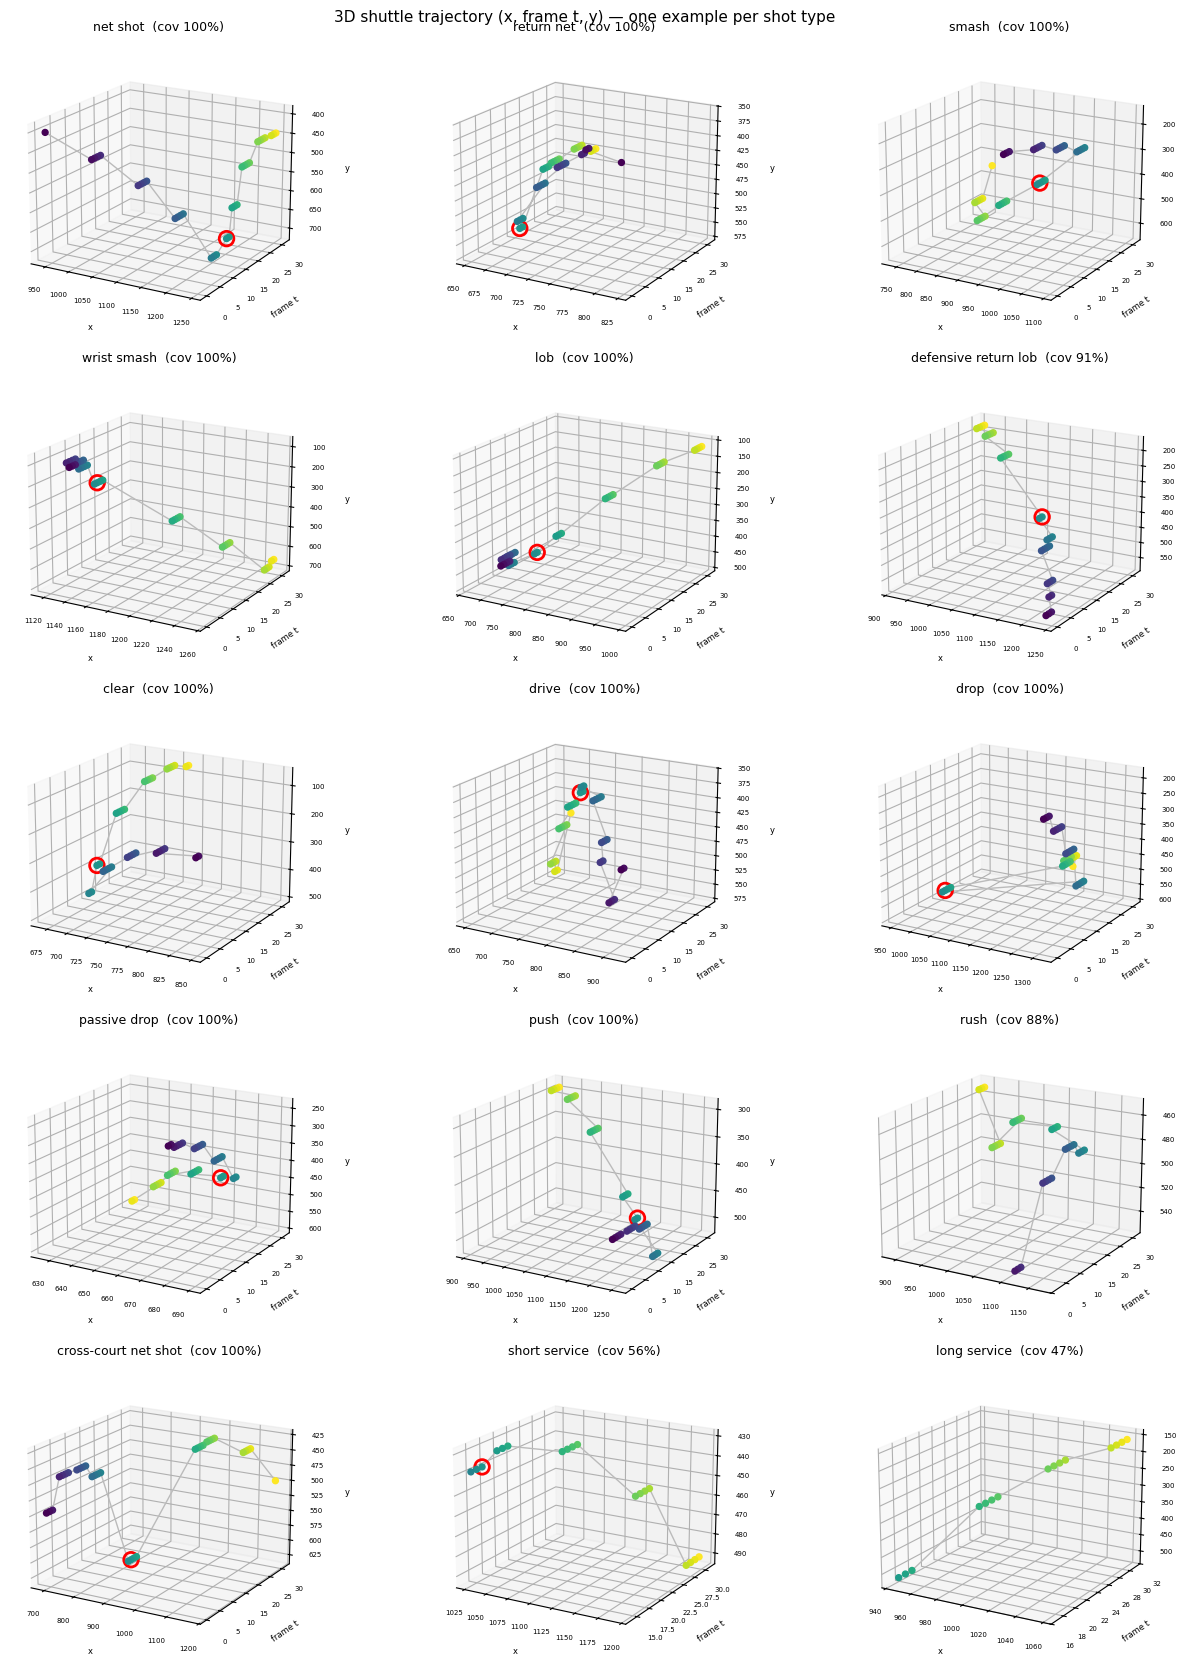

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run7/xattn_3d_per_type.png


In [16]:
# ── §9b·4 — 3D shuttle trajectory, one example per shot type ────────────
# Axes (x px, frame t, y px). The frame axis unrolls the path over time so
# incoming/outgoing arcs don't overlap; z inverted so up = high in the air.
# Same example shot as §9b·3 (highest tracking coverage, correct prediction).
# Depends on by_type / rows_present / _coverage from §9b·1 — run that first.

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)

CONTACT_FRAME = SHOT_WINDOW // 2  # t=16

n    = len(rows_present)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig  = plt.figure(figsize=(4.6 * ncol, 3.4 * nrow))

for k, name in enumerate(rows_present):
    rs    = by_type[name]
    cands = [r for r in rs if r['pred'] == r['label']] or rs
    ex    = sorted(cands, key=lambda r: (-_coverage(r['shuttle']),
                                         r['frame_num'], r['rally_key']))[0]
    sh = ex['shuttle']
    xs, ys  = sh[0], sh[1]
    visible = (xs != 0) | (ys != 0)
    ax = fig.add_subplot(nrow, ncol, k + 1, projection='3d')
    if visible.any():
        vi = np.where(visible)[0]
        ax.plot(xs[vi], vi, ys[vi], '-', color='#bbbbbb', lw=1)
        ax.scatter(xs[vi], vi, ys[vi], c=vi, cmap='viridis', vmin=0,
                   vmax=SHOT_WINDOW - 1, s=18, depthshade=False)
        if visible[CONTACT_FRAME]:
            ax.scatter([xs[CONTACT_FRAME]], [CONTACT_FRAME], [ys[CONTACT_FRAME]],
                       facecolors='none', edgecolors='red', s=110, lw=2)
    ax.set_xlabel('x', fontsize=6); ax.set_ylabel('frame t', fontsize=6)
    ax.set_zlabel('y', fontsize=6)
    ax.invert_zaxis()  # image y grows downward → invert so up = high
    ax.tick_params(labelsize=5)
    ax.view_init(elev=18, azim=-60)
    ax.set_title(f'{name}  (cov {_coverage(sh):.0%})', fontsize=9)

fig.suptitle('3D shuttle trajectory (x, frame t, y) — one example per shot type',
             fontsize=11)
plt.tight_layout()
out = ABLATION_DIR / 'xattn_3d_per_type.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')
